# Importing package

In [167]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Loading dataset

In [168]:
df = pd.read_csv('laptop_data.csv')

In [169]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [170]:
df.describe()

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


# 1. Data Cleaning and Preparation

In [172]:
df.drop(columns='Unnamed: 0', inplace = True)

## Checking missing data

In [173]:
df.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

## Checking duplicated data

In [174]:
df.duplicated().sum()

29

In [175]:
duplicated = df[df.duplicated()]
print(duplicated.head)
print( )
print(duplicated.shape)

<bound method NDFrame.head of      Company            TypeName  Inches  \
1274    Asus            Notebook    15.6   
1275    Asus           Ultrabook    13.3   
1276    Dell            Notebook    15.6   
1277    Acer            Notebook    15.6   
1278    Dell            Notebook    15.6   
1279  Lenovo            Notebook    15.6   
1280      HP            Notebook    15.6   
1281    Dell            Notebook    15.6   
1282      HP             Netbook    11.6   
1283    Asus            Notebook    15.6   
1284  Lenovo  2 in 1 Convertible    14.0   
1285  Lenovo  2 in 1 Convertible    13.3   
1286  Lenovo            Notebook    14.0   
1287      HP            Notebook    15.6   
1288    Asus            Notebook    15.6   
1289    Asus           Ultrabook    13.3   
1290    Dell            Notebook    15.6   
1291    Acer            Notebook    15.6   
1292    Dell            Notebook    15.6   
1293  Lenovo            Notebook    15.6   
1294      HP            Notebook    15.6   
12

In [176]:
clean_df = df.drop_duplicates()
clean_df.duplicated().sum()

0

# 2. Exploratory Data Analysis (EDA)

## Checking Price(target)

In [177]:
df['Price'].describe()

count      1303.000000
mean      59870.042910
std       37243.201786
min        9270.720000
25%       31914.720000
50%       52054.560000
75%       79274.246400
max      324954.720000
Name: Price, dtype: float64

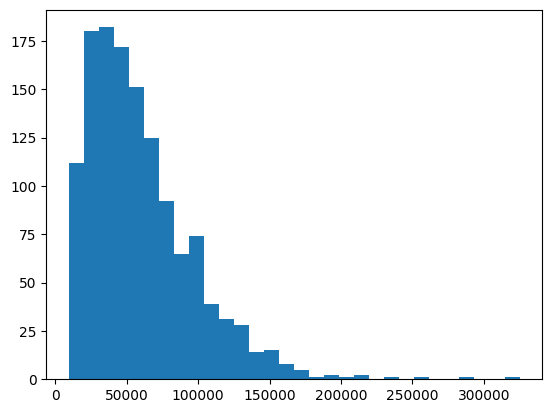

In [178]:
plt.hist(df['Price'], bins = 30)
plt.show()

<Axes: xlabel='Price', ylabel='Count'>

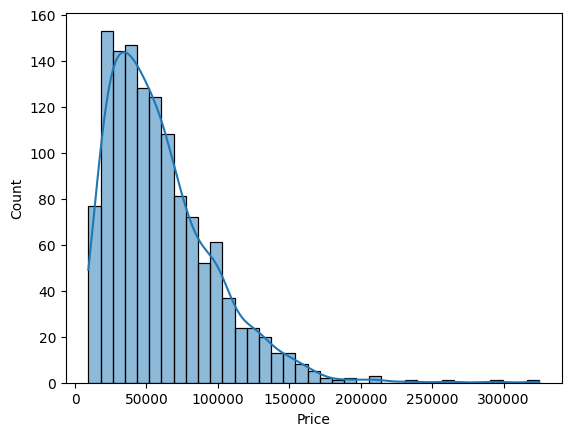

In [179]:
sns.histplot(df['Price'], kde = True)

<Axes: xlabel='Price', ylabel='Count'>

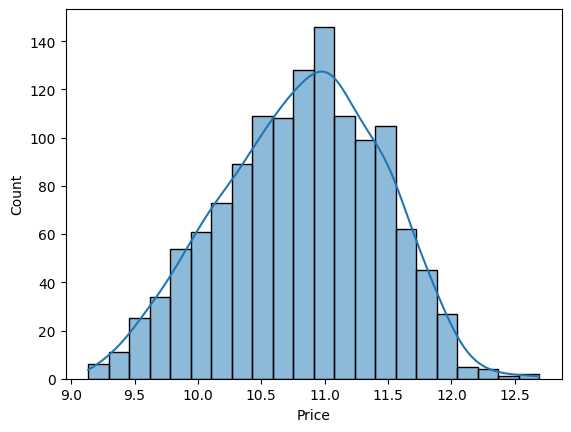

In [180]:
sns.histplot(np.log1p(df['Price']), kde = True)

In [181]:
X = df.drop(columns=['Price'])
y = np.log1p(df['Price'])

## Exploring 'Company' Column

In [182]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

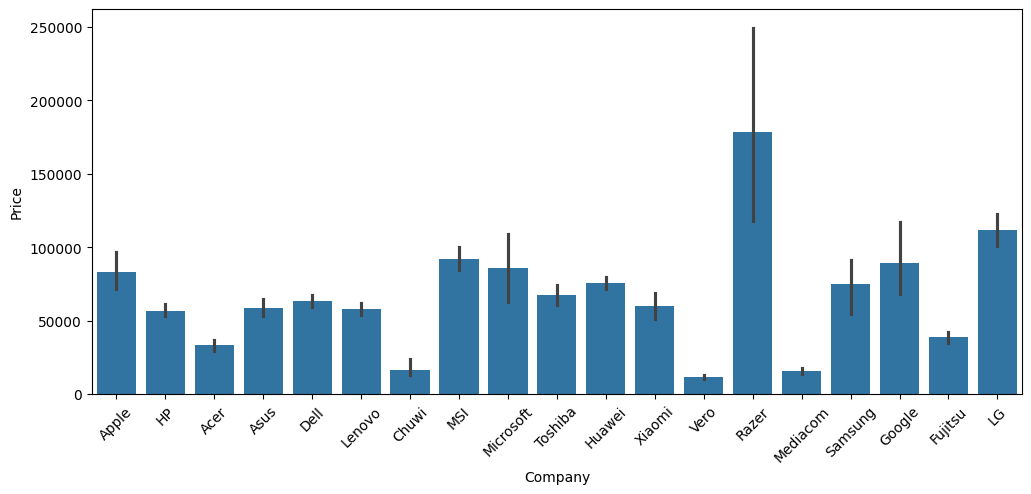

In [183]:
plt.figure(figsize = (12,5))
sns.barplot(x = df['Company'], y = df['Price'])
plt.xticks(rotation = 45)
plt.show()

## Exploring Typename Column

In [184]:
df['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

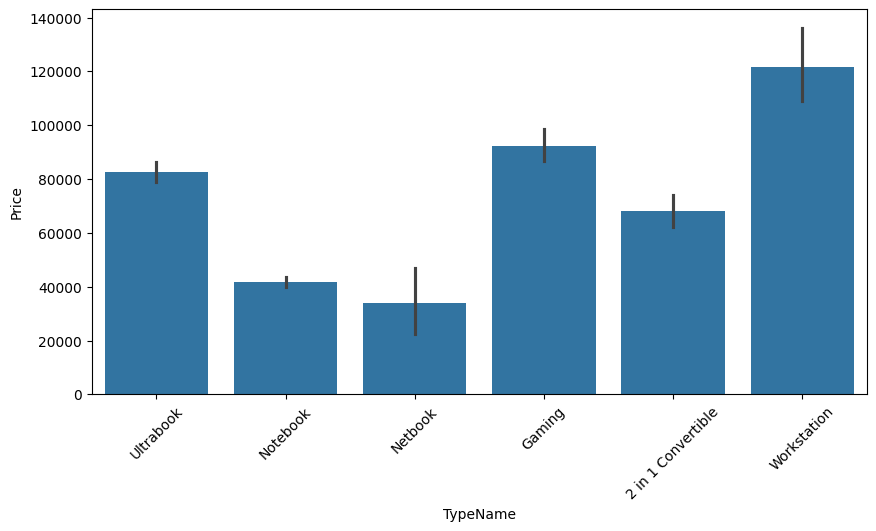

In [185]:
plt.figure(figsize = (10,5))
sns.barplot(x = df['TypeName'], y = df['Price'])
plt.xticks(rotation = 45)
plt.show()

## Exploring RAM

In [186]:
df['Ram'].value_counts()

Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64

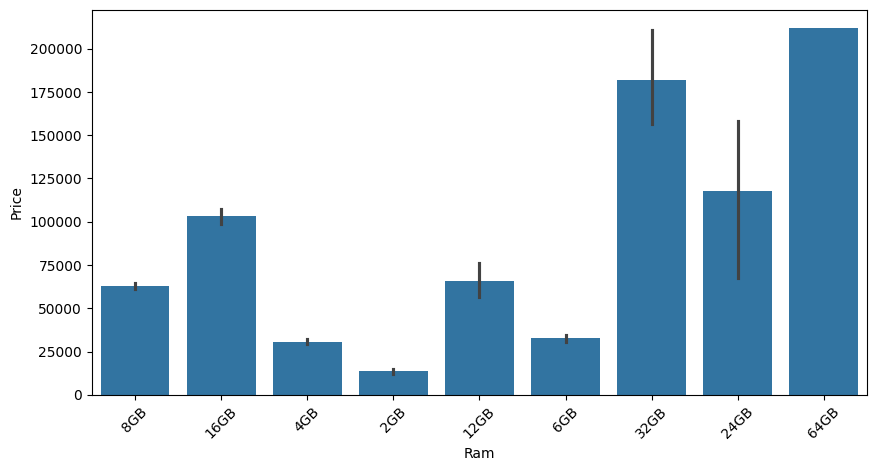

In [187]:
plt.figure(figsize=(10,5))
sns.barplot(x = df['Ram'], y = df['Price'])
plt.xticks(rotation = 45)
plt.show()

In [188]:
df['Ram'] = (
    df['Ram']
    .str.replace('GB','')
    .astype(int)
)

In [189]:
print(df['Ram'].dtype)

int32


## Exploring Weight Column

In [190]:
df['Weight'].head()

0    1.37kg
1    1.34kg
2    1.86kg
3    1.83kg
4    1.37kg
Name: Weight, dtype: object

In [191]:
print(df['Weight'].dtype)

object


In [192]:
df['Weight'] = (
    df['Weight']
    .str.replace('kg','')
    .astype(float)
)

In [193]:
print(df['Weight'].dtype)

float64


In [194]:
df[['Weight','Price']].corr(numeric_only=True)

,Weight,Price
Weight,1.00000,0.21037
Price,0.21037,1.00000


<Axes: xlabel='Weight', ylabel='Price'>

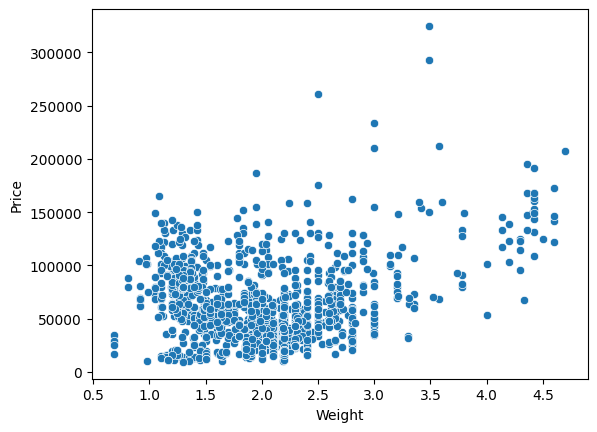

In [195]:
sns.scatterplot(x = df['Weight'], y = df['Price'])

# 3. Feature Engineering

## Memory Column

In [196]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [197]:
df.groupby('Memory')['Price'].mean().sort_values(ascending=False).head(15)

Memory
1TB SSD +  1TB HDD               193092.048000
512GB SSD +  1.0TB Hybrid        172627.200000
240GB SSD                        165168.000000
1TB SSD                          163676.160000
256GB SSD +  1.0TB Hybrid        146519.467200
512GB SSD +  1TB HDD             133223.823771
8GB SSD                          119826.720000
64GB Flash Storage +  1TB HDD    106187.040000
512GB SSD                         99144.010983
256GB SSD +  1TB HDD              98895.788778
512GB SSD +  2TB HDD              98514.720000
512GB SSD +  256GB SSD            85672.108800
256GB SSD +  2TB HDD              81833.497920
512GB SSD +  512GB SSD            79866.720000
256GB SSD +  500GB HDD            79769.217600
Name: Price, dtype: float64

In [198]:
# checking unexpected data
df['Memory'].sample(15, random_state = 42)

479                256GB SSD
1022               256GB SSD
298                  1TB HDD
1265                 1TB HDD
774                256GB SSD
115                256GB SSD
582                128GB SSD
527                  2TB HDD
380     128GB SSD +  1TB HDD
101                500GB HDD
420                512GB SSD
712                  1TB HDD
1249               256GB SSD
1295                 1TB HDD
1214    256GB SSD +  1TB HDD
Name: Memory, dtype: object

In [199]:
df2 = df.copy()

In [200]:
df2['Memory'].head()

0              128GB SSD
1    128GB Flash Storage
2              256GB SSD
3              512GB SSD
4              256GB SSD
Name: Memory, dtype: object

In [201]:
df[df2['Memory'].str.contains('TB')]['Memory'].unique()

array(['1TB HDD', '128GB SSD +  1TB HDD', '256GB SSD +  1TB HDD',
       '256GB SSD +  2TB HDD', '2TB HDD', '1.0TB Hybrid',
       '512GB SSD +  1TB HDD', '1TB SSD', '128GB SSD +  2TB HDD',
       '512GB SSD +  2TB HDD', '64GB Flash Storage +  1TB HDD',
       '1TB HDD +  1TB HDD', '1TB SSD +  1TB HDD', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [202]:
memory = df2['Memory'].copy()

In [203]:
memory = memory.str.replace('1.0TB', '1024GB')
memory = memory.str.replace('1TB', '1024GB')
memory = memory.str.replace('2TB', '2048GB')

memory[memory.str.contains('TB')]

Series([], Name: Memory, dtype: object)

In [204]:
memory[memory.str.contains(r'\+')].head()

21    128GB SSD +  1024GB HDD
28     256GB SSD +  256GB SSD
37    128GB SSD +  1024GB HDD
41    256GB SSD +  1024GB HDD
47    256GB SSD +  1024GB HDD
Name: Memory, dtype: object

In [205]:
memory_df = memory.str.split(' + ', expand = True, regex = False)
memory_df.head(30)

,0,1
0,128GB SSD,None
1,128GB Flash Storage,None
2,256GB SSD,None
3,512GB SSD,None
4,256GB SSD,None
5,500GB HDD,None
6,256GB Flash Storage,None
7,256GB Flash Storage,None
8,512GB SSD,None
9,256GB SSD,None


In [206]:
memory_df.iloc[21]

0      128GB SSD
1     1024GB HDD
Name: 21, dtype: object

In [207]:
memory_df.iloc[21,0].split()

['128GB', 'SSD']

In [208]:
memory_df.iloc[21,1].split()

['1024GB', 'HDD']

In [209]:
memory_df[0].head()

0              128GB SSD
1    128GB Flash Storage
2              256GB SSD
3              512GB SSD
4              256GB SSD
Name: 0, dtype: object

In [210]:
memory_df[0].str.split().str[0].str.replace('GB','').astype(int).head()

0    128
1    128
2    256
3    512
4    256
Name: 0, dtype: int32

In [211]:
memory_df[0].head(20)

0               128GB SSD
1     128GB Flash Storage
2               256GB SSD
3               512GB SSD
4               256GB SSD
5               500GB HDD
6     256GB Flash Storage
7     256GB Flash Storage
8               512GB SSD
9               256GB SSD
10              500GB HDD
11              500GB HDD
12              256GB SSD
13              256GB SSD
14              256GB SSD
15              256GB SSD
16              256GB SSD
17              512GB SSD
18             1024GB HDD
19              128GB SSD
Name: 0, dtype: object

In [212]:
memory_df['drive1_size'] = (
    memory_df[0]
    .str.split()
    .str[0]
    .str.replace('GB','')
    .astype(int)
)

In [213]:
memory_df[1].isna().sum()

1095

In [214]:
memory_df[1].notna().sum()

208

In [215]:
memory_df[1].str.split().str[0].head(30)

0       None
1       None
2       None
3       None
4       None
5       None
6       None
7       None
8       None
9       None
10      None
11      None
12      None
13      None
14      None
15      None
16      None
17      None
18      None
19      None
20      None
21    1024GB
22      None
23      None
24      None
25      None
26      None
27      None
28     256GB
29      None
Name: 1, dtype: object

In [216]:
memory_df[0].str.split().str[1].head(20)

0       SSD
1     Flash
2       SSD
3       SSD
4       SSD
5       HDD
6     Flash
7     Flash
8       SSD
9       SSD
10      HDD
11      HDD
12      SSD
13      SSD
14      SSD
15      SSD
16      SSD
17      SSD
18      HDD
19      SSD
Name: 0, dtype: object

In [217]:
memory_df[1].str.split().str[1].head(30)

0     None
1     None
2     None
3     None
4     None
5     None
6     None
7     None
8     None
9     None
10    None
11    None
12    None
13    None
14    None
15    None
16    None
17    None
18    None
19    None
20    None
21     HDD
22    None
23    None
24    None
25    None
26    None
27    None
28     SSD
29    None
Name: 1, dtype: object

In [218]:
memory_df['drive1_type'] = memory_df[0].str.split().str[1]

In [219]:
memory_df[['drive1_size', 'drive1_type']].head(20)

,drive1_size,drive1_type
0,128,SSD
1,128,Flash
2,256,SSD
3,512,SSD
4,256,SSD
5,500,HDD
6,256,Flash
7,256,Flash
8,512,SSD
9,256,SSD


In [220]:
memory_df.head()

,0,1,drive1_size,drive1_type
0,128GB SSD,None,128,SSD
1,128GB Flash Storage,None,128,Flash
2,256GB SSD,None,256,SSD
3,512GB SSD,None,512,SSD
4,256GB SSD,None,256,SSD


np.where(condition, value_if_true, value_if_false)

In [221]:
memory_df['SSD'] = np.where(
    memory_df['drive1_type'] == 'SSD',
    memory_df['drive1_size'],
    0
)

In [222]:
memory_df[['drive1_size', 'drive1_type', 'SSD']].head(20)

,drive1_size,drive1_type,SSD
0,128,SSD,128
1,128,Flash,0
2,256,SSD,256
3,512,SSD,512
4,256,SSD,256
5,500,HDD,0
6,256,Flash,0
7,256,Flash,0
8,512,SSD,512
9,256,SSD,256


In [223]:
memory_df['HDD'] = np.where(
    memory_df['drive1_type'] == 'HDD',
    memory_df['drive1_size'],
    0
)

In [224]:
memory_df['Flash'] = np.where(
    memory_df['drive1_type'] == 'Flash',
    memory_df['drive1_size'],
    0
)

In [225]:
memory_df['Hybrid'] = np.where(
    memory_df['drive1_type'] == 'Hybrid',
    memory_df['drive1_size'],
    0
)

In [226]:
memory_df[[
    'drive1_size',
    'drive1_type',
    'SSD',
    'HDD',
    'Flash',
    'Hybrid'
]].head(20)

,drive1_size,drive1_type,SSD,HDD,Flash,Hybrid
0,128,SSD,128,0,0,0
1,128,Flash,0,0,128,0
2,256,SSD,256,0,0,0
3,512,SSD,512,0,0,0
4,256,SSD,256,0,0,0
5,500,HDD,0,500,0,0
6,256,Flash,0,0,256,0
7,256,Flash,0,0,256,0
8,512,SSD,512,0,0,0
9,256,SSD,256,0,0,0


In [227]:
memory_df['drive2_size'] = (
    memory_df[1]
    .str.split()
    .str[0]
    .str.replace('GB','')
    .fillna('0')
    .astype(int)
)

In [228]:
memory_df['drive2_type'] = (
    memory_df[1]
    .str.split()
    .str[1]
    .fillna('NoDrive')
)

In [229]:
memory_df.loc[[21, 28],['drive2_size', 'drive2_type']]

,drive2_size,drive2_type
21,1024,HDD
28,256,SSD


In [230]:
memory_df['SSD_2'] = np.where(
    memory_df['drive2_type'] == 'SSD',
    memory_df['drive2_size'],
    0
)

In [231]:
memory_df['HDD_2'] = np.where(
    memory_df['drive2_type'] == 'HDD',
    memory_df['drive2_size'],
    0
)

memory_df['Flash_2'] = np.where(
    memory_df['drive2_type'] == 'Flash',
    memory_df['drive2_size'],
    0
)

memory_df['Hybrid_2'] = np.where(
    memory_df['drive2_type'] == 'Hybrid',
    memory_df['drive2_size'],
    0
)

In [232]:
memory_df.loc[
[21,28],
[
    'SSD_2',
    'HDD_2',
    'Flash_2',
    
]
]

,SSD_2,HDD_2,Flash_2
21,0,1024,0
28,256,0,0


In [233]:
memory_df['SSD_total'] = memory_df['SSD'] + memory_df['SSD_2']
memory_df['HDD_total'] = memory_df['HDD'] + memory_df['HDD_2']
memory_df['Flash_total'] = memory_df['Flash'] + memory_df['Flash_2']
memory_df['Hybrid_total'] = memory_df['Hybrid'] + memory_df['Hybrid_2']

In [234]:
memory_df.head(30)

,0,1,drive1_size,drive1_type,SSD,HDD,Flash,Hybrid,drive2_size,drive2_type,SSD_2,HDD_2,Flash_2,Hybrid_2,SSD_total,HDD_total,Flash_total,Hybrid_total
0,128GB SSD,None,128,SSD,128,0,0,0,0,NoDrive,0,0,0,0,128,0,0,0
1,128GB Flash Storage,None,128,Flash,0,0,128,0,0,NoDrive,0,0,0,0,0,0,128,0
2,256GB SSD,None,256,SSD,256,0,0,0,0,NoDrive,0,0,0,0,256,0,0,0
3,512GB SSD,None,512,SSD,512,0,0,0,0,NoDrive,0,0,0,0,512,0,0,0
4,256GB SSD,None,256,SSD,256,0,0,0,0,NoDrive,0,0,0,0,256,0,0,0
5,500GB HDD,None,500,HDD,0,500,0,0,0,NoDrive,0,0,0,0,0,500,0,0
6,256GB Flash Storage,None,256,Flash,0,0,256,0,0,NoDrive,0,0,0,0,0,0,256,0
7,256GB Flash Storage,None,256,Flash,0,0,256,0,0,NoDrive,0,0,0,0,0,0,256,0
8,512GB SSD,None,512,SSD,512,0,0,0,0,NoDrive,0,0,0,0,512,0,0,0
9,256GB SSD,None,256,SSD,256,0,0,0,0,NoDrive,0,0,0,0,256,0,0,0


In [235]:
memory_df[['SSD_total',
           'HDD_total',
           'Flash_total',
           'Hybrid_total']].describe()

,SSD_total,HDD_total,Flash_total,Hybrid_total
count,1303.000000,1303.000000,1303.000000,1303.000000
mean,184.027629,422.477360,4.555641,9.034536
std,188.268689,528.006298,30.274090,94.738890
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,256.000000,0.000000,0.000000,0.000000
75%,256.000000,1024.000000,0.000000,0.000000
max,1024.000000,2048.000000,512.000000,1024.000000


In [236]:
memory_df.loc[[21, 28],
[
    'SSD_total',
    'HDD_total',
    'Flash_total',
    'Hybrid_total'
]]

,SSD_total,HDD_total,Flash_total,Hybrid_total
21,128,1024,0,0
28,512,0,0,0


In [237]:
df2['SSD'] = memory_df['SSD_total']
df2['HHD'] = memory_df['HDD_total']
df2['Flash'] = memory_df['Flash_total']
df2['Hybrid'] = memory_df['Hybrid_total']

df2 = df2.drop(columns = ['Memory'])
df2.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Gpu,OpSys,Weight,Price,SSD,HHD,Flash,Hybrid
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,128,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,Intel HD Graphics 620,No OS,1.86,30636.0000,256,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,512,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,256,0,0,0


In [238]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Gpu               1303 non-null   object 
 7   OpSys             1303 non-null   object 
 8   Weight            1303 non-null   float64
 9   Price             1303 non-null   float64
 10  SSD               1303 non-null   int32  
 11  HHD               1303 non-null   int32  
 12  Flash             1303 non-null   int32  
 13  Hybrid            1303 non-null   int32  
dtypes: float64(3), int32(5), object(6)
memory usage: 117.2+ KB


In [239]:
df2.to_csv('laptop_clean_memory.csv', index=False)

## ScreenResolution Column

In [240]:
df2['ScreenResolution'].sample(20, random_state = 42) 

479                       IPS Panel Full HD 1920x1080
1022                      IPS Panel Full HD 1920x1080
298                                 Full HD 1920x1080
1265                      IPS Panel Full HD 1920x1080
774                                          1366x768
115         IPS Panel Full HD / Touchscreen 1920x1080
582                                 Full HD 1920x1080
527                                          1366x768
380                       IPS Panel Full HD 1920x1080
101                                 Full HD 1920x1080
420     IPS Panel 4K Ultra HD / Touchscreen 3840x2160
712                                 Full HD 1920x1080
1249                 Quad HD+ / Touchscreen 3200x1800
1295                                         1366x768
1214                                Full HD 1920x1080
221                       IPS Panel Full HD 1920x1080
542                      IPS Panel Quad HD+ 3200x1800
813                                 Full HD 1920x1080
275                         

In [241]:
df2['Touchscreen'] = df2['ScreenResolution'].str.contains('Touchscreen').astype(int)

In [242]:
df2['IPS'] = df2['ScreenResolution'].str.contains('IPS Panel').astype(int)

In [243]:
df2[['ScreenResolution','IPS']].sample(20, random_state = 42)

,ScreenResolution,IPS
479,IPS Panel Full HD 1920x1080,1
1022,IPS Panel Full HD 1920x1080,1
298,Full HD 1920x1080,0
1265,IPS Panel Full HD 1920x1080,1
774,1366x768,0
115,IPS Panel Full HD / Touchscreen 1920x1080,1
582,Full HD 1920x1080,0
527,1366x768,0
380,IPS Panel Full HD 1920x1080,1
101,Full HD 1920x1080,0


In [244]:
# Creating a temporary column
df2['Resolution'] = df2['ScreenResolution'].str.split().str[-1]

In [245]:
df2['Resolution'].str.split('x', expand=True).head()

,0,1
0,2560,1600
1,1440,900
2,1920,1080
3,2880,1800
4,2560,1600


In [246]:
# Splitting the resolution column into X and Y
df2[['X_res', 'Y_res']] = (df2['Resolution'].str.split('x', expand=True))

In [247]:
df2['X_res'] = df2['X_res'].astype(int)
df2['Y_res'] = df2['Y_res'].astype(int)

In [248]:
df2[['Resolution','X_res','Y_res']].head()

,Resolution,X_res,Y_res
0,2560x1600,2560,1600
1,1440x900,1440,900
2,1920x1080,1920,1080
3,2880x1800,2880,1800
4,2560x1600,2560,1600


In [249]:
df2['Inches'].dtype

dtype('float64')

In [250]:
df2['DiagonalPixels'] = np.sqrt(
    df2['X_res']**2 +
    df2['Y_res']
)

In [251]:
df2['PPI'] = (
    df2['DiagonalPixels'] /
    df2['Inches']
)

In [252]:
df2[['PPI','Price']].corr(numeric_only = True)

,PPI,Price
PPI,1.00000,0.47496
Price,0.47496,1.00000


In [253]:
print(df2[['X_res','Price']].corr(numeric_only = True))
print(df2[['Y_res','Price']].corr(numeric_only = True))

          X_res     Price
X_res  1.000000  0.556529
Price  0.556529  1.000000
          Y_res     Price
Y_res  1.000000  0.552809
Price  0.552809  1.000000


## CPU Column

In [254]:
# inspect pattern randomly
df2['Cpu'].sample(20, random_state = 42)

479       Intel Core i5 7200U 2.5GHz
1022      Intel Core i5 7200U 2.5GHz
298      AMD A10-Series 9600P 2.4GHz
1265     Intel Core i7 6700HQ 2.6GHz
774       Intel Core i5 6200U 2.3GHz
115       Intel Core i5 8250U 1.6GHz
582       Intel Core i3 7100U 2.4GHz
527         Intel Core i3 6006U 2GHz
380      Intel Core i7 7700HQ 2.8GHz
101     AMD E-Series E2-9000e 1.5GHz
420      Intel Core i7 7700HQ 2.8GHz
712       Intel Core i5 7200U 2.5GHz
1249       Intel Core i5 7Y54 1.2GHz
1295      Intel Core i7 7500U 2.7GHz
1214     Intel Core i7 7700HQ 2.8GHz
221       Intel Core i5 8250U 1.6GHz
542       Intel Core i7 7500U 2.7GHz
813       Intel Core i7 7500U 2.7GHz
275       Intel Core i7 7500U 2.7GHz
746       Intel Core i7 7500U 2.7GHz
Name: Cpu, dtype: object

In [255]:
df2['Cpu'].apply(lambda x: " ".join(x.split()[:3])).value_counts()

Cpu
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
Intel Celeron Quad            8
AMD A6-Series 9220            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
AMD A8-Series 7410            4
Intel Atom x5-Z8550           4
Intel Pentium Dual            3
AMD A9-Series 9410            3
AMD Ryzen 1700                3
AMD A9-Series A9-9420         2
AMD A10-Series 9620P          2
Intel Atom X5-Z8350           2
AMD E-Series E2-9000e         2
Intel Xeon E3-1535M           2
Intel Xeon E3-1505M           2
AMD E-Series 7110             2
AMD A10-Series 9600P          2
AMD A6-Series A6-9220         2
AMD A10-Series A10-9620P      2
AMD Ryzen 1600                1
Intel Atom x5-Z8300           1
AMD E-Series E2-6110          1
AMD FX 9830P                  1
AMD E-Series E2-9000          1
AMD 

In [256]:
df2['Cpu'].str.split().str[-1].head(20)

0     2.3GHz
1     1.8GHz
2     2.5GHz
3     2.7GHz
4     3.1GHz
5       3GHz
6     2.2GHz
7     1.8GHz
8     1.8GHz
9     1.6GHz
10    2.5GHz
11      2GHz
12    2.8GHz
13      2GHz
14    1.2GHz
15    2.3GHz
16    2.7GHz
17    2.9GHz
18    2.4GHz
19    1.6GHz
Name: Cpu, dtype: object

In [257]:
df2['CpuSpeed'] = (df2['Cpu'].str.split().str[-1].str.replace('GHz','').astype(float))

In [258]:
df2[['Cpu','CpuSpeed']].head()

,Cpu,CpuSpeed
0,Intel Core i5 2.3GHz,2.3
1,Intel Core i5 1.8GHz,1.8
2,Intel Core i5 7200U 2.5GHz,2.5
3,Intel Core i7 2.7GHz,2.7
4,Intel Core i5 3.1GHz,3.1


In [259]:
df2['CpuSpeed'].describe()

count    1303.000000
mean        2.298772
std         0.506340
min         0.900000
25%         2.000000
50%         2.500000
75%         2.700000
max         3.600000
Name: CpuSpeed, dtype: float64

In [260]:
df2['Cpu'].apply(lambda x: " ".join(x.split()[:4])).value_counts()

Cpu
Intel Core i5 7200U            193
Intel Core i7 7700HQ           147
Intel Core i7 7500U            135
Intel Core i3 6006U             81
Intel Celeron Dual Core         80
                              ... 
Intel Xeon E3-1535M v6           1
Intel Core i7 2.8GHz             1
AMD E-Series E2-9000 2.2GHz      1
AMD FX 9830P 3GHz                1
Intel Core i7 6920HQ             1
Name: count, Length: 96, dtype: int64

In [261]:
df2['Cpu'].sample(30, random_state = 1)

644                 Intel Core i3 6006U 2GHz
1275                Intel Core M 6Y30 0.9GHz
163              Intel Core i7 7700HQ 2.8GHz
1008              Intel Core i5 7200U 2.5GHz
909               Intel Core i7 7500U 2.7GHz
268               Intel Core i7 8550U 1.8GHz
1133              Intel Core i7 7500U 2.7GHz
983               Intel Core i5 6200U 2.3GHz
1277    Intel Celeron Dual Core N3060 1.6GHz
904               Intel Core i5 7200U 2.5GHz
1122              Intel Core i5 6200U 2.3GHz
986               Intel Core i5 7200U 2.5GHz
693               Intel Core i7 7500U 2.7GHz
111               Intel Core i7 7560U 2.4GHz
1051              Intel Core i7 7500U 2.7GHz
88               Intel Core i7 7700HQ 2.8GHz
1026              Intel Core i5 7200U 2.5GHz
826               Intel Core i5 7200U 2.5GHz
390              Intel Core i7 7700HQ 2.8GHz
1005              Intel Core i5 6300U 2.4GHz
536               Intel Core i5 8250U 1.6GHz
1062              Intel Core i5 7200U 2.5GHz
65        

In [262]:
df2['Cpu'][~(
    df2['Cpu'].str.contains('i3|i5|i7|Core M|Celeron|Pentium|Atom|Xeon|Ryzen|A-Series|E-Series|Cortex')
)].unique()

array(['AMD A9-Series 9420 3GHz', 'AMD A6-Series 9220 2.5GHz',
       'AMD FX 9830P 3GHz', 'AMD A6-Series 9220 2.9GHz',
       'AMD A10-Series A10-9620P 2.5GHz', 'AMD A6-Series A6-9220 2.5GHz',
       'AMD A10-Series 9600P 2.4GHz', 'AMD A8-Series 7410 2.2GHz',
       'AMD A12-Series 9720P 2.7GHz', 'AMD A12-Series 9720P 3.6GHz',
       'AMD A10-Series 9620P 2.5GHz', 'AMD A9-Series A9-9420 3GHz',
       'AMD A9-Series 9420 2.9GHz', 'AMD A6-Series 7310 2GHz',
       'AMD A12-Series 9700P 2.5GHz', 'AMD A4-Series 7210 2.2GHz',
       'AMD FX 8800P 2.1GHz', 'AMD A9-Series 9410 2.9GHz'], dtype=object)

In [263]:
df2['Cpu'].str.extract(r'(A\d+-Series)')[0].value_counts()

0
A9-Series     17
A6-Series     11
A12-Series     8
A10-Series     6
A8-Series      4
A4-Series      1
Name: count, dtype: int64

In [264]:
print(df2['Cpu'].str.contains('Ryzen').sum())
print(df2['Cpu'].str.contains('Xeon').sum())
print(df2['Cpu'].str.contains('Atom').sum())
print(df2['Cpu'].str.contains('FX').sum())
print(df2['Cpu'].str.contains('Cortex').sum())

4
4
13
2
1


In [265]:
# Assign all CPU families to 'Other' as the default category 
df2['CpuFamily'] = 'Other'

In [266]:
# Assign Intel core families
df2.loc[df2['Cpu'].str.contains('i3'), 'CpuFamily'] = 'i3'
df2.loc[df2['Cpu'].str.contains('i5'), 'CpuFamily'] = 'i5'
df2.loc[df2['Cpu'].str.contains('i7'), 'CpuFamily'] = 'i7'

In [267]:
# Assigning remaining intel families
df2.loc[df2['Cpu'].str.contains('Core M'), 'CpuFamily'] = 'Core M'
df2.loc[df2['Cpu'].str.contains('Celeron'), 'CpuFamily'] = 'Celeron'
df2.loc[df2['Cpu'].str.contains('Pentium'), 'CpuFamily'] = 'Pentium'
df2.loc[df2['Cpu'].str.contains('Atom'), 'CpuFamily'] = 'Atom'
df2.loc[df2['Cpu'].str.contains('Xeon'), 'CpuFamily'] = 'Xeon'

In [268]:
# Assign AMD Families
df2.loc[df2['Cpu'].str.contains('Ryzen'), 'CpuFamily'] = 'Ryzen'
df2.loc[df2['Cpu'].str.contains(r'A\d+-Series'), 'CpuFamily'] = 'AMD A-Series'
df2.loc[df2['Cpu'].str.contains('E-Series'), 'CpuFamily'] = 'AMD E-Series'

In [269]:
df2['CpuFamily'].value_counts()

CpuFamily
i7              527
i5              423
i3              136
Celeron          88
AMD A-Series     47
Pentium          30
Core M           19
Atom             13
AMD E-Series      9
Ryzen             4
Xeon              4
Other             3
Name: count, dtype: int64

In [270]:
df2[['CpuSpeed','Price']].corr(numeric_only=True)

,CpuSpeed,Price
CpuSpeed,1.000000,0.430293
Price,0.430293,1.000000


In [271]:
df2.groupby('CpuFamily')['Price'].mean().sort_values(ascending = False)

CpuFamily
Xeon            190955.520000
Ryzen            89803.440000
i7               85023.110883
Core M           70555.058526
i5               54080.012426
Other            41860.320000
i3               28857.830929
AMD A-Series     26766.534332
Pentium          23205.571200
Celeron          17013.823691
Atom             16778.527754
AMD E-Series     16031.300800
Name: Price, dtype: float64

## GPU Column

In [272]:
df2['Gpu'].sample(30, random_state = 42)

479       Intel HD Graphics 620
1022      Intel HD Graphics 620
298           AMD Radeon R5 430
1265    Nvidia GeForce GTX 960M
774       Intel HD Graphics 520
115      Intel UHD Graphics 620
582       Intel HD Graphics 620
527       Nvidia GeForce 920MX 
380     Nvidia GeForce GTX 1050
101               AMD Radeon R2
420     Nvidia GeForce GTX 1050
712       Intel HD Graphics 620
1249      Intel HD Graphics 615
1295         AMD Radeon R5 M430
1214    Nvidia GeForce GTX 1060
221      Intel UHD Graphics 620
542       Intel HD Graphics 620
813     Nvidia GeForce GT 940MX
275       Intel HD Graphics 620
746       Intel HD Graphics 620
585     Nvidia GeForce GTX 980M
1297        Nvidia GeForce 920M
1067      Intel HD Graphics 520
718       Intel HD Graphics 400
218      Intel UHD Graphics 620
44         Nvidia GeForce 150MX
566       Intel HD Graphics 620
966       Intel HD Graphics 620
848       Intel HD Graphics 620
716       Intel HD Graphics 620
Name: Gpu, dtype: object

In [273]:
# Check GPU brand
df2['Gpu'].str.split().str[0].value_counts()

Gpu
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [274]:
df2['GpuBrand'] = df2['Gpu'].str.split().str[0]

In [275]:
df2.groupby('GpuBrand')['Price'].mean().sort_values(ascending = False)

GpuBrand
Nvidia    79380.500040
Intel     53718.258994
AMD       41326.507680
ARM       35111.520000
Name: Price, dtype: float64

In [276]:
df2['Gpu'].apply(lambda x: " ".join(x.split()[:2])).value_counts()

Gpu
Intel HD          639
Nvidia GeForce    368
AMD Radeon        173
Intel UHD          68
Nvidia Quadro      31
Intel Iris         14
AMD FirePro         5
AMD R4              1
Nvidia GTX          1
AMD R17M-M1-70      1
Intel Graphics      1
ARM Mali            1
Name: count, dtype: int64

In [277]:
df2['GpuFamily'] = (df2['Gpu'].apply(lambda x: " ".join(x.split()[:2])))

In [278]:
df2.groupby('GpuFamily')['Price'].mean().sort_values(ascending = False)

GpuFamily
Nvidia GTX        149130.720000
Nvidia Quadro     130989.378426
Intel Iris         96180.142629
AMD FirePro        87230.016000
Nvidia GeForce     74843.474361
Intel UHD          64243.331576
Intel HD           51675.352315
Intel Graphics     48964.320000
AMD R17M-M1-70     43316.640000
AMD Radeon         40104.311806
ARM Mali           35111.520000
AMD R4             21258.720000
Name: Price, dtype: float64

In [279]:
rare_gpu = [
    'Nvidia GTX',
    'AMD R4',
    'AMD R17M-M1-70',
    'Intel Graphics',
    'ARM Mali'
]
df2.loc[df2['GpuFamily'].isin(rare_gpu), 'GpuFamily'] = 'Other'

In [280]:
df2.groupby('GpuFamily')['Price'].mean().sort_values(ascending = False)

GpuFamily
Nvidia Quadro     130989.378426
Intel Iris         96180.142629
AMD FirePro        87230.016000
Nvidia GeForce     74843.474361
Intel UHD          64243.331576
Other              59556.384000
Intel HD           51675.352315
AMD Radeon         40104.311806
Name: Price, dtype: float64

In [281]:
df2['GpuFamily'].value_counts()

GpuFamily
Intel HD          639
Nvidia GeForce    368
AMD Radeon        173
Intel UHD          68
Nvidia Quadro      31
Intel Iris         14
Other               5
AMD FirePro         5
Name: count, dtype: int64

In [282]:
df2['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

In [283]:
df2.groupby('TypeName')['Price'].mean().sort_values(ascending = False)

TypeName
Workstation           121497.525683
Gaming                 92247.960187
Ultrabook              82489.713429
2 in 1 Convertible     68326.360066
Notebook               41669.149113
Netbook                33898.440960
Name: Price, dtype: float64

In [284]:
df2['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [285]:
df2.groupby('OpSys')['Price'].mean().sort_values(ascending = False)

OpSys
macOS           93220.327385
Windows 7       89864.783040
Windows 10 S    68543.654400
Mac OS X        67285.780200
Windows 10      62238.471367
Linux           32877.429445
No OS           31327.219200
Chrome OS       29495.018667
Android         23123.520000
Name: Price, dtype: float64

In [286]:
df2['OpSysFamily'] = 'Other'
df2.loc[df2['OpSys'].str.contains('Windows'), 'OpSysFamily'] = 'Windows'
df2.loc[df2['OpSys'].str.contains('macOS|Mac OS X'), 'OpSysFamily'] = 'Mac'
df2.loc[df2['OpSys'].str.contains('Linux'), 'OpSysFamily'] = 'Linux'
df2.loc[df2['OpSys'].str.contains('Chrome'), 'OpSysFamily'] = 'Chrome OS'
df2.loc[df2['OpSys'].str.contains('No OS'), 'OpSysFamily'] = 'No OS'

In [287]:
df2['OpSysFamily'].value_counts()

OpSysFamily
Windows      1125
No OS          66
Linux          62
Chrome OS      27
Mac            21
Other           2
Name: count, dtype: int64

In [288]:
df2.groupby('OpSysFamily')['Price'].mean().sort_values(ascending = False)

OpSysFamily
Mac          83340.499886
Windows      63388.360691
Linux        32877.429445
No OS        31327.219200
Chrome OS    29495.018667
Other        23123.520000
Name: Price, dtype: float64

## Checking Company Column

In [289]:
df2['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

In [290]:
df2.groupby('Company')['Price'].mean().sort_values(ascending = False)

Company
Razer        178282.491429
LG           111834.720000
MSI           92116.226133
Google        89386.080000
Microsoft     85903.788000
Apple         83340.499886
Huawei        75870.720000
Samsung       75308.320000
Toshiba       67549.050000
Dell          63193.755782
Xiaomi        60390.882000
Asus          58830.143878
Lenovo        57882.563200
HP            56891.044222
Fujitsu       38841.120000
Acer          33394.615969
Chuwi         16745.726400
Mediacom      15717.600000
Vero          11584.404000
Name: Price, dtype: float64

## Checking RAM Column

In [291]:
df2['Ram'].describe()

count    1303.000000
mean        8.382195
std         5.084665
min         2.000000
25%         4.000000
50%         8.000000
75%         8.000000
max        64.000000
Name: Ram, dtype: float64

In [292]:
df2[['Ram','Price']].corr(numeric_only = True)

,Ram,Price
Ram,1.000000,0.743007
Price,0.743007,1.000000


## Checking Weight Column

In [293]:
df2['Weight'].describe()

count    1303.000000
mean        2.038734
std         0.665475
min         0.690000
25%         1.500000
50%         2.040000
75%         2.300000
max         4.700000
Name: Weight, dtype: float64

In [294]:
df2[['Weight','Price']].corr(numeric_only = True)

,Weight,Price
Weight,1.00000,0.21037
Price,0.21037,1.00000


## Final Check

In [295]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Gpu               1303 non-null   object 
 7   OpSys             1303 non-null   object 
 8   Weight            1303 non-null   float64
 9   Price             1303 non-null   float64
 10  SSD               1303 non-null   int32  
 11  HHD               1303 non-null   int32  
 12  Flash             1303 non-null   int32  
 13  Hybrid            1303 non-null   int32  
 14  Touchscreen       1303 non-null   int32  
 15  IPS               1303 non-null   int32  
 16  Resolution        1303 non-null   object 


In [296]:
df2.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Gpu,OpSys,Weight,Price,...,Resolution,X_res,Y_res,DiagonalPixels,PPI,CpuSpeed,CpuFamily,GpuBrand,GpuFamily,OpSysFamily
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,...,2560x1600,2560,1600,2560.312481,192.504698,2.3,i5,Intel,Intel Iris,Mac
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,...,1440x900,1440,900,1440.312466,108.294170,1.8,i5,Intel,Intel HD,Mac
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,Intel HD Graphics 620,No OS,1.86,30636.0000,...,1920x1080,1920,1080,1920.281229,123.094951,2.5,i5,Intel,Intel HD,No OS
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,...,2880x1800,2880,1800,2880.312483,187.033278,2.7,i7,AMD,AMD Radeon,Mac
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,...,2560x1600,2560,1600,2560.312481,192.504698,3.1,i5,Intel,Intel Iris,Mac


# 4. Feature Selection and Dataset Finalization

In [297]:
drop_cols = [
    'ScreenResolution',
    'Cpu',
    'Gpu',
    'OpSys',
    'Resolution',
    'DiagonalPixels'
]

In [298]:
model_df = df2.copy()
model_df.columns.tolist()

['Company',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'Cpu',
 'Ram',
 'Gpu',
 'OpSys',
 'Weight',
 'Price',
 'SSD',
 'HHD',
 'Flash',
 'Hybrid',
 'Touchscreen',
 'IPS',
 'Resolution',
 'X_res',
 'Y_res',
 'DiagonalPixels',
 'PPI',
 'CpuSpeed',
 'CpuFamily',
 'GpuBrand',
 'GpuFamily',
 'OpSysFamily']

In [299]:
model_df = model_df.drop(columns= drop_cols)

In [300]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1303 non-null   object 
 1   TypeName     1303 non-null   object 
 2   Inches       1303 non-null   float64
 3   Ram          1303 non-null   int32  
 4   Weight       1303 non-null   float64
 5   Price        1303 non-null   float64
 6   SSD          1303 non-null   int32  
 7   HHD          1303 non-null   int32  
 8   Flash        1303 non-null   int32  
 9   Hybrid       1303 non-null   int32  
 10  Touchscreen  1303 non-null   int32  
 11  IPS          1303 non-null   int32  
 12  X_res        1303 non-null   int32  
 13  Y_res        1303 non-null   int32  
 14  PPI          1303 non-null   float64
 15  CpuSpeed     1303 non-null   float64
 16  CpuFamily    1303 non-null   object 
 17  GpuBrand     1303 non-null   object 
 18  GpuFamily    1303 non-null   object 
 19  OpSysF

In [301]:
model_df.head()

,Company,TypeName,Inches,Ram,Weight,Price,SSD,HHD,Flash,Hybrid,Touchscreen,IPS,X_res,Y_res,PPI,CpuSpeed,CpuFamily,GpuBrand,GpuFamily,OpSysFamily
0,Apple,Ultrabook,13.3,8,1.37,71378.6832,128,0,0,0,0,1,2560,1600,192.504698,2.3,i5,Intel,Intel Iris,Mac
1,Apple,Ultrabook,13.3,8,1.34,47895.5232,0,0,128,0,0,0,1440,900,108.294170,1.8,i5,Intel,Intel HD,Mac
2,HP,Notebook,15.6,8,1.86,30636.0000,256,0,0,0,0,0,1920,1080,123.094951,2.5,i5,Intel,Intel HD,No OS
3,Apple,Ultrabook,15.4,16,1.83,135195.3360,512,0,0,0,0,1,2880,1800,187.033278,2.7,i7,AMD,AMD Radeon,Mac
4,Apple,Ultrabook,13.3,8,1.37,96095.8080,256,0,0,0,0,1,2560,1600,192.504698,3.1,i5,Intel,Intel Iris,Mac


In [302]:
X = model_df.drop(columns = 'Price')
y = np.log1p(model_df['Price'])

In [303]:
cat_features = (
    X.select_dtypes(include = 'object').columns.tolist()
)

In [304]:
num_features = (
    X.select_dtypes(exclude = 'object').columns.tolist()
)

In [305]:
cat_features

['Company', 'TypeName', 'CpuFamily', 'GpuBrand', 'GpuFamily', 'OpSysFamily']

In [306]:
num_features

['Inches',
 'Ram',
 'Weight',
 'SSD',
 'HHD',
 'Flash',
 'Hybrid',
 'Touchscreen',
 'IPS',
 'X_res',
 'Y_res',
 'PPI',
 'CpuSpeed']

# 5. Data Preprocessing For Modeling

In [307]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [308]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_features)
        
    ], remainder = 'passthrough'
)

In [309]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

# 6. Linear Regression

In [310]:
lr_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('regressor',LinearRegression())
])

In [311]:
lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [312]:
y_pred_lr = lr_model.predict(X_test)
y_pred_price_lr = np.expm1(y_pred_lr)
y_test_price_lr = np.expm1(y_test)

## 6.1. Model Evaluation

In [344]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

In [345]:
print('MAE:', mae_lr)
print('RMSE:', rmse_lr)
print('R2:', r2_lr)

MAE: 0.1769923346391736
RMSE: 0.2262646975743239
R2: 0.8555451698591783


## 6.2. Cross Validation

In [314]:
from sklearn.model_selection import cross_val_score

In [315]:
scores = cross_val_score(
    lr_model, X, y, cv = 5, scoring = 'neg_mean_absolute_error'
)

In [316]:
print('CV_score:',-scores)
print('Avg MAE:', np.mean(-scores))

CV_score: [0.19262737 0.1727139  0.18939442 0.22370548 0.22140096]
Avg MAE: 0.19996842459229466


# 7. Random Forest Regression

In [317]:
from sklearn.ensemble import RandomForestRegressor

In [318]:
rf_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('regressor',RandomForestRegressor(random_state = 42))
])

## 7.1 GridSearchCV for Random Forest Regression

In [319]:
# defining the hyperparameters
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

In [320]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator = rf_model,
    param_grid = param_grid,
    cv = 5,
    scoring = 'neg_mean_absolute_error',
    n_jobs = -1,
    verbose = 2
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regressor__max_depth': [10, 20, ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], 'regressor__n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [321]:
grid_search.best_params_

{'regressor__max_depth': 20,
 'regressor__min_samples_leaf': 1,
 'regressor__min_samples_split': 2,
 'regressor__n_estimators': 300}

In [322]:
-grid_search.best_score_

0.15601045544548803

In [323]:
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

In [341]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [342]:
print('MAE:', mae_rf)
print('RMSE:', rmse_rf)
print('R2:', r2_rf)

MAE: 0.1551418009428686
RMSE: 0.20712415647202487
R2: 0.8789513432557083


# 8. XGBoost

In [325]:
from xgboost import XGBRegressor

In [326]:
xg_model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('regressor',XGBRegressor(random_state = 42, objective = 'reg:squarederror'))
])

In [327]:
param_dist = {
    'regressor__n_estimators': [100,200,300,400,500,600,700,800],
    'regressor__learning_rate': [0.01,0.03,0.05,0.1,0.2],
    'regressor__max_depth': [3,4,5,6,7,8,9],
    'regressor__min_child_weight': [1,3,5,7],
    'regressor__subsample': [0.6,0.8,1.0],
    'regressor__colsample_bytree': [0.6,0.8,1.0]
}

In [328]:
# GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator = xg_model,
    param_distributions = param_dist,
    n_iter = 50,
    cv = 50,
    scoring = 'neg_mean_absolute_error',
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'regressor__colsample_bytree': [0.6, 0.8, ...], 'regressor__learning_rate': [0.01, 0.03, ...], 'regressor__max_depth': [3, 4, ...], 'regressor__min_child_weight': [1, 3, ...], ...}"
,n_iter,50
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,50
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [329]:
random_search.best_params_

{'regressor__subsample': 0.8,
 'regressor__n_estimators': 700,
 'regressor__min_child_weight': 1,
 'regressor__max_depth': 9,
 'regressor__learning_rate': 0.03,
 'regressor__colsample_bytree': 0.6}

In [330]:
-random_search.best_score_

0.13823266562549943

In [331]:
best_xg = random_search.best_estimator_
y_pred_xg = best_xg.predict(X_test)

In [332]:
print('MAE:', mean_absolute_error(y_test, y_pred_xg))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_xg)))
print('R2:', r2_score(y_test, y_pred_xg))

MAE: 0.1348199548135547
RMSE: 0.18670257468100201
R2: 0.9016444020274598


In [336]:
mae_xg = mean_absolute_error(y_test, y_pred_xg)
rmse_xg = np.sqrt(mean_squared_error(y_test, y_pred_xg))
r2_xg = r2_score(y_test, y_pred_xg)

In [340]:
print('MAE:', mae_xg)
print('RMSE:', rmse_xg)
print('R2:', r2_xg)

MAE: 0.1348199548135547
RMSE: 0.18670257468100201
R2: 0.9016444020274598


# Model Comparison

In [346]:
results = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE' : [mae_lr, mae_rf, mae_xg],
    'RMSE' : [rmse_lr, rmse_rf, rmse_xg],
    'R2': [r2_lr, r2_rf, r2_xg]
})

In [347]:
results

,Model,MAE,RMSE,R2
0,Linear Regression,0.176992,0.226265,0.855545
1,Random Forest,0.155142,0.207124,0.878951
2,XGBoost,0.134820,0.186703,0.901644
